<a href="https://colab.research.google.com/github/Mahekd/interpretable-nlp-sexism-detection/blob/main/notebooks/01_eda_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Exploratory Data Analysis (EDA)

In [5]:
df = pd.read_csv('/content/drive/MyDrive/EDOS_DATA/edos_labelled_aggregated.csv')
df.head()

,rewire_id,text,label_sexist,label_category,label_vector,split
0,sexism2022_english-9609,"In Nigeria, if you rape a woman, the men rape ...",not sexist,none,none,dev
1,sexism2022_english-16993,"Then, she's a keeper. 😉",not sexist,none,none,train
2,sexism2022_english-13149,This is like the Metallica video where the poo...,not sexist,none,none,train
3,sexism2022_english-13021,woman?,not sexist,none,none,train
4,sexism2022_english-966,I bet she wished she had a gun,not sexist,none,none,dev


In [6]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(20000, 6)
rewire_id         object
text              object
label_sexist      object
label_category    object
label_vector      object
split             object
dtype: object
rewire_id         0
text              0
label_sexist      0
label_category    0
label_vector      0
split             0
dtype: int64


In [8]:
print("Task A - Sexist vs Not Sexist(Binary classifcation):")
print(df['label_sexist'].value_counts())

print("\nTask B - Category:")
print(df['label_category'].value_counts())

print("\nTask C - Vector:")
print(df['label_vector'].value_counts())

print("\nSplit distribution:")
print(df['split'].value_counts())

Task A - Sexist vs Not Sexist(Binary classifcation):
label_sexist
not sexist    15146
sexist         4854
Name: count, dtype: int64

Task B - Category:
label_category
none                                        15146
2. derogation                                2271
3. animosity                                 1665
4. prejudiced discussions                     475
1. threats, plans to harm and incitement      443
Name: count, dtype: int64

Task C - Vector:
label_vector
none                                                               15146
2.1 descriptive attacks                                             1024
2.2 aggressive and emotive attacks                                   961
3.1 casual use of gendered slurs, profanities, and insults           910
3.2 immutable gender differences and gender stereotypes              596
4.2 supporting systemic discrimination against women as a group      368
1.2 incitement and encouragement of harm                             363
2.3 dehumanisin

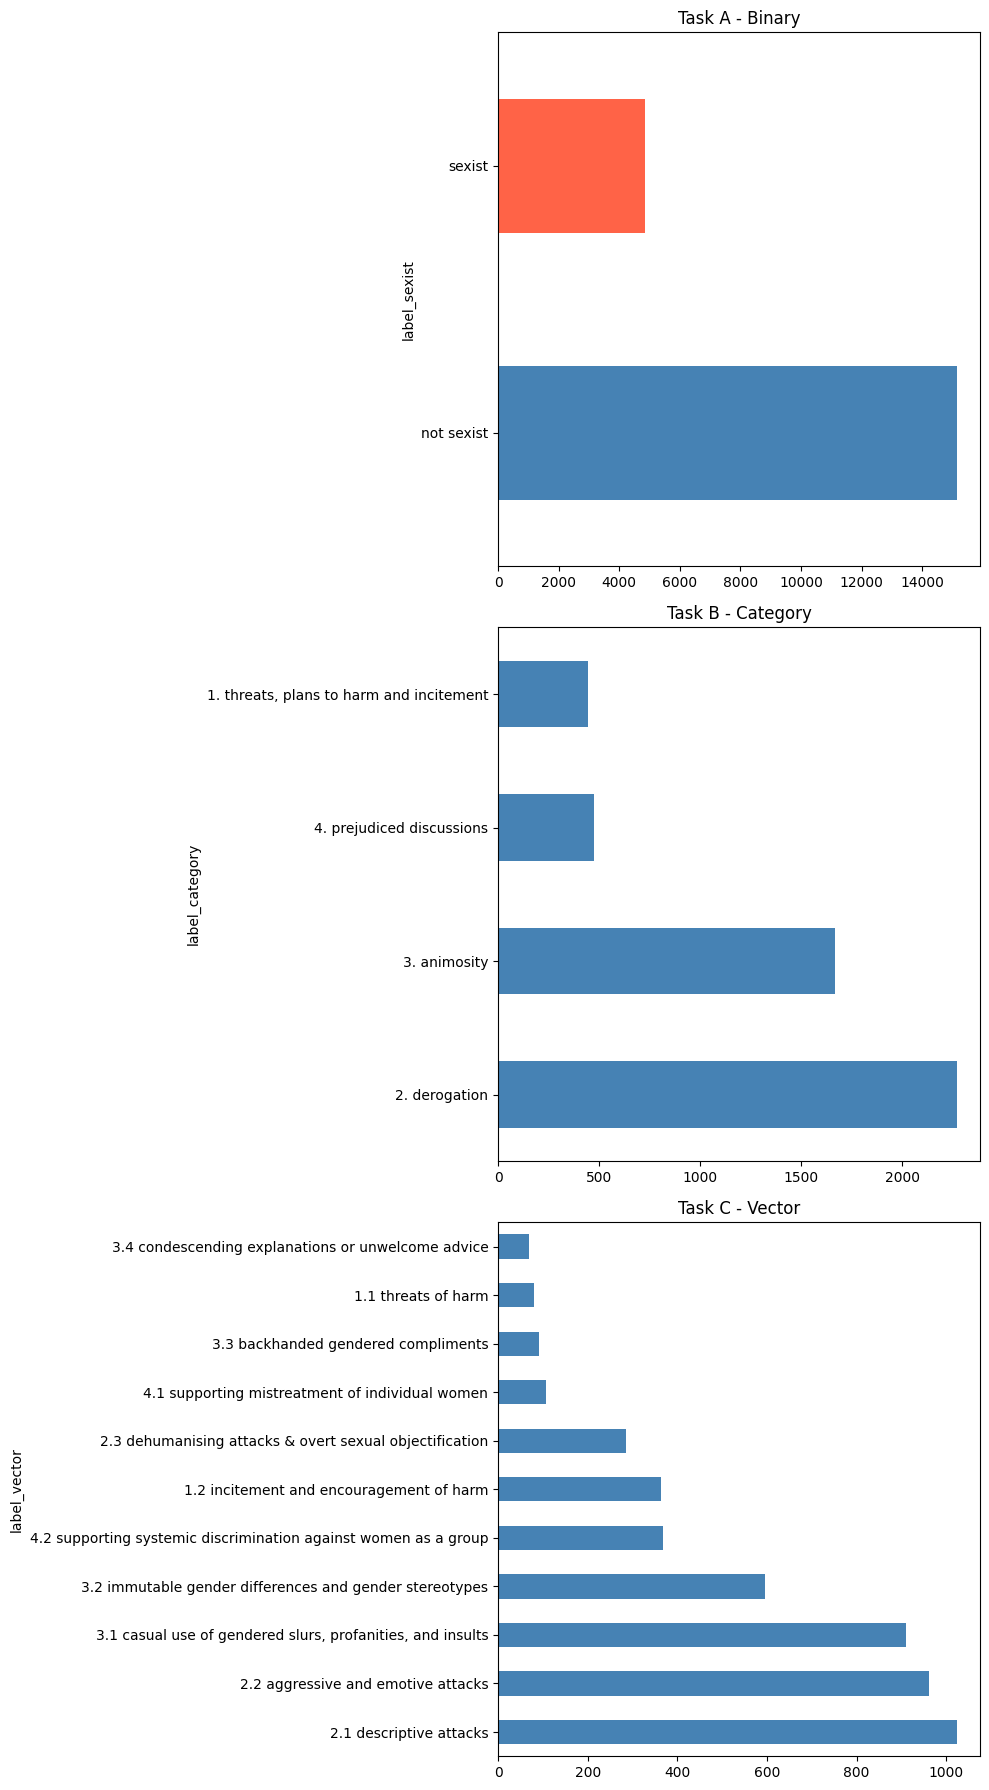

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

df['label_sexist'].value_counts().plot(kind='barh', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Task A - Binary')

df[df['label_category'] != 'none']['label_category'].value_counts().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Task B - Category')

df[df['label_vector'] != 'none']['label_vector'].value_counts().plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Task C - Vector')

plt.tight_layout()
plt.show()

## 2. Pre-Processing